<a href="https://colab.research.google.com/github/rohith154-vsr/ML-2-LAB/blob/main/LP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LEARNED RULE

 LowIncome(x) AND HighGPA(x)  ->  Eligible(x)

LEARNING HISTORY
Round 0: (most general)                                                    | pos_covered=4  neg_covered=5
Round 1: LowIncome(x)                                                      | pos_covered=4  neg_covered=1
Round 2: LowIncome(x) AND HighGPA(x)                                       | pos_covered=4  neg_covered=0


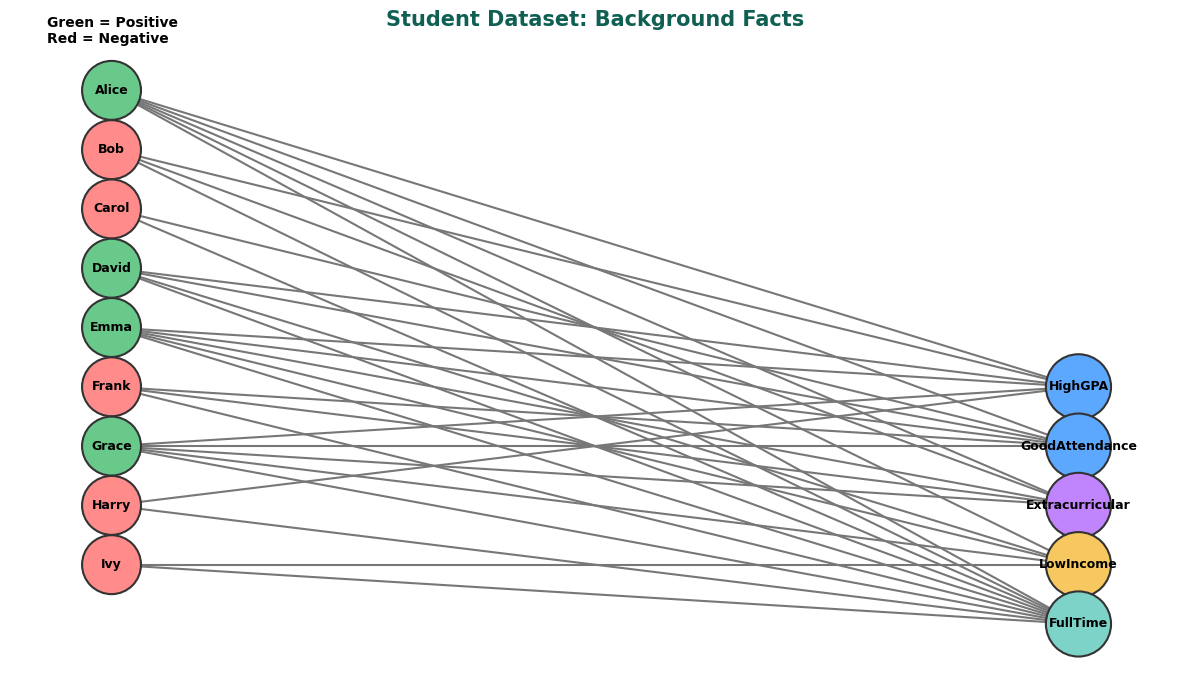

/tmp/ipykernel_1025/1499340513.py:572: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


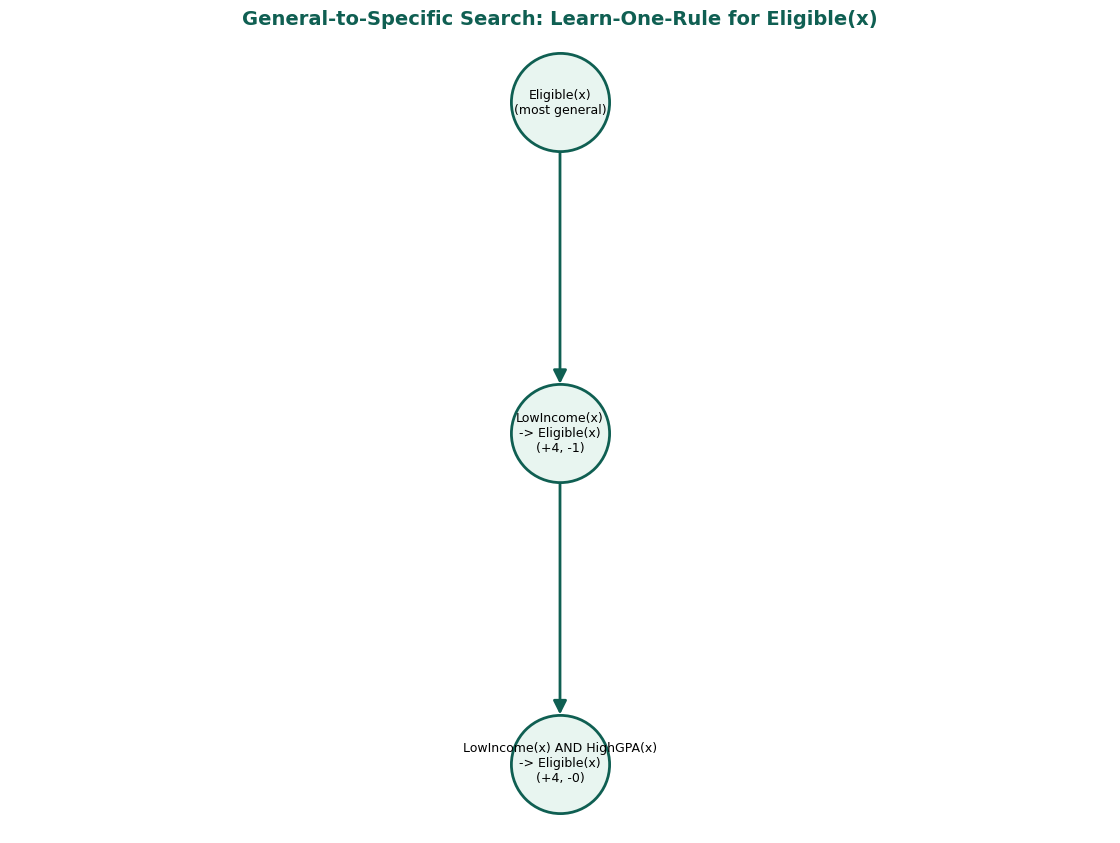

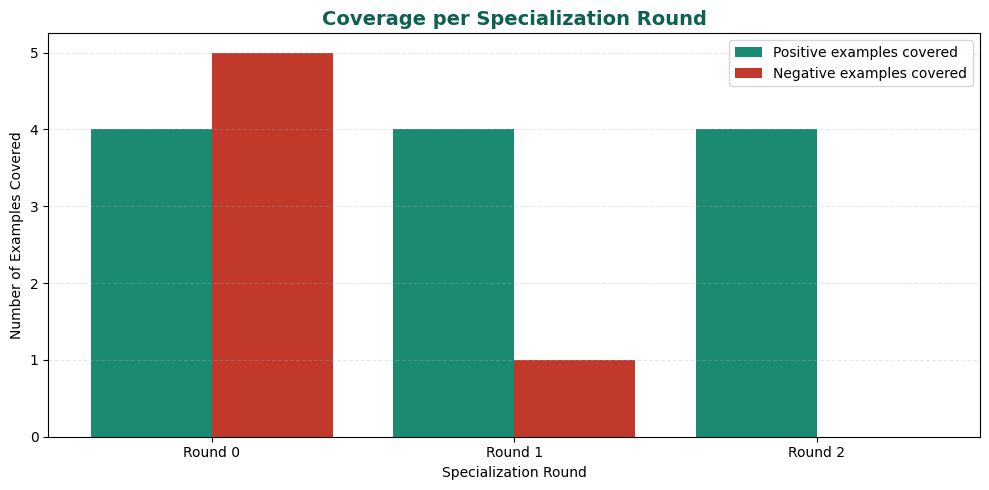

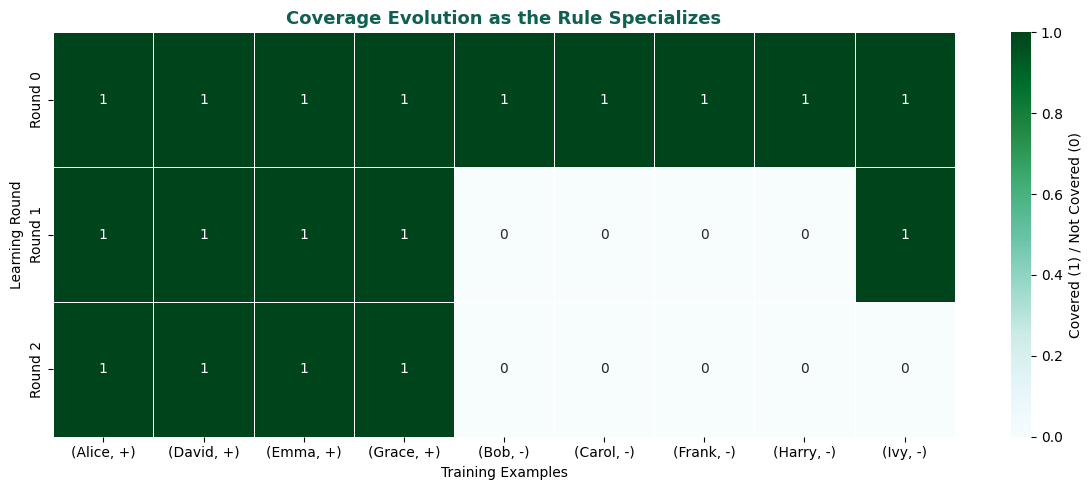


FINAL VERIFICATION

Final learned rule:
LowIncome(x) AND HighGPA(x)  ->  Eligible(x)

Verification against training data:
Student Actual Class LowIncome(x) HighGPA(x)  Rule Result Correct
  Alice            +            T          T     Eligible     YES
  David            +            T          T     Eligible     YES
   Emma            +            T          T     Eligible     YES
  Grace            +            T          T     Eligible     YES
    Bob            -            F          T Not Eligible     YES
  Carol            -            F          F Not Eligible     YES
  Frank            -            F          F Not Eligible     YES
  Harry            -            F          T Not Eligible     YES
    Ivy            -            T          F Not Eligible     YES

SUMMARY

Learned Rule:
LowIncome(x) AND HighGPA(x)  ->  Eligible(x)

Positive examples covered: 4
Negative examples covered: 0
Total examples covered: 4

Rule learning completed successfully.


In [2]:
# ============================================================
# STUDENT SCHOLARSHIP RULE LEARNING
# General-to-Specific Learn-One-First-Order-Rule
# ============================================================

!pip install networkx matplotlib pandas seaborn -q

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ============================================================
# 1. DATASET - STUDENT SCHOLARSHIP ELIGIBILITY
# ============================================================
#
# Goal:
# Learn a rule for:
#
#     Eligible(x) <- ?
#
# Positive examples (+):
# Students who are eligible for scholarship
#
# Negative examples (-):
# Students who are not eligible
#
# ------------------------------------------------------------
# Background facts:
#
# HighGPA(x)
# GoodAttendance(x)
# Extracurricular(x)
# LowIncome(x)
#
# The intended learned rule is approximately:
#
# HighGPA(x) AND GoodAttendance(x) AND LowIncome(x)
#                         ->
#                    Eligible(x)
# ============================================================

facts = {

    "HighGPA": {
        ("Alice",),
        ("Bob",),
        ("David",),
        ("Emma",),
        ("Grace",),
        ("Harry",)
    },

    "GoodAttendance": {
        ("Alice",),
        ("Carol",),
        ("David",),
        ("Emma",),
        ("Frank",),
        ("Grace",)
    },

    "Extracurricular": {
        ("Alice",),
        ("Bob",),
        ("Emma",),
        ("Frank",),
        ("Grace",)
    },

    "LowIncome": {
        ("Alice",),
        ("David",),
        ("Emma",),
        ("Grace",),
        ("Ivy",)
    },

    "FullTime": {
        ("Alice",),
        ("Bob",),
        ("Carol",),
        ("David",),
        ("Emma",),
        ("Frank",),
        ("Grace",),
        ("Harry",),
        ("Ivy",)
    }
}


# ============================================================
# TRAINING EXAMPLES
# ============================================================
#
# Format:
#     (student, unused_variable, class)
#
# True  = scholarship eligible
# False = scholarship not eligible
# ============================================================

examples = [

    # Positive examples
    ("Alice", None, True),
    ("David", None, True),
    ("Emma", None, True),
    ("Grace", None, True),

    # Negative examples
    ("Bob", None, False),
    ("Carol", None, False),
    ("Frank", None, False),
    ("Harry", None, False),
    ("Ivy", None, False),
]


# ============================================================
# 2. CANDIDATE LITERALS
# ============================================================
#
# These are the possible conditions that the algorithm
# can add to the rule.
# ============================================================

candidate_literals = {

    "HighGPA(x)":
        lambda x, y: (x,) in facts["HighGPA"],

    "GoodAttendance(x)":
        lambda x, y: (x,) in facts["GoodAttendance"],

    "Extracurricular(x)":
        lambda x, y: (x,) in facts["Extracurricular"],

    "LowIncome(x)":
        lambda x, y: (x,) in facts["LowIncome"],

    "FullTime(x)":
        lambda x, y: (x,) in facts["FullTime"],
}


# ============================================================
# 3. EVALUATE A RULE
# ============================================================

def evaluate_rule(literal_names, examples):

    pos = 0
    neg = 0
    covered = []

    for x, y, label in examples:

        # A rule covers the example only if
        # ALL literals in the rule are satisfied.

        satisfied = all(
            candidate_literals[lit](x, y)
            for lit in literal_names
        )

        if satisfied:

            covered.append((x, y, label))

            if label:
                pos += 1
            else:
                neg += 1

    return pos, neg, covered


# ============================================================
# 4. LEARN-ONE-FIRST-ORDER-RULE
# General -> Specific Search
# ============================================================

def learn_one_rule(examples, candidate_literals):

    rule_body = []

    history = []

    round_num = 0

    while True:

        # Evaluate current rule
        pos, neg, covered = evaluate_rule(
            rule_body,
            examples
        )

        # Save information for visualization
        history.append({

            "round": round_num,

            "rule":
                " AND ".join(rule_body)
                if rule_body
                else "(most general)",

            "pos_covered": pos,

            "neg_covered": neg,

        })

        # Stop when no negative examples remain
        if neg == 0:
            break

        # ----------------------------------------------------
        # Try adding every possible literal
        # ----------------------------------------------------

        scores = {}

        for lit in candidate_literals:

            if lit in rule_body:
                continue

            trial_body = rule_body + [lit]

            p, n, _ = evaluate_rule(
                trial_body,
                examples
            )

            # Score:
            # Higher positive coverage
            # Lower negative coverage
            score = p - n

            scores[lit] = (score, p, n)

        # ----------------------------------------------------
        # Select best literal
        # ----------------------------------------------------

        best_lit = max(
            scores,
            key=lambda l: scores[l][0]
        )

        rule_body.append(best_lit)

        round_num += 1

    # Final evaluation
    final_pos, final_neg, final_covered = evaluate_rule(
        rule_body,
        examples
    )

    return (
        rule_body,
        history,
        final_covered
    )


# ============================================================
# 5. RUN RULE LEARNING
# ============================================================

rule_body, history, final_covered = learn_one_rule(
    examples,
    candidate_literals
)

rule_str = (
    " AND ".join(rule_body)
    + "  ->  Eligible(x)"
)

print("=" * 70)
print("LEARNED RULE")
print("=" * 70)

print("\n", rule_str)

print("\n" + "=" * 70)
print("LEARNING HISTORY")
print("=" * 70)

for h in history:

    print(
        "Round {}: {:65s} | "
        "pos_covered={}  neg_covered={}".format(
            h["round"],
            h["rule"],
            h["pos_covered"],
            h["neg_covered"]
        )
    )


# ============================================================
# 6. VISUALIZATION 1
# STUDENT FACT GRAPH
# ============================================================
#
# This replaces the family tree visualization.
#
# Students are connected to the properties they possess.
# ============================================================

SG = nx.Graph()

students = [
    "Alice",
    "Bob",
    "Carol",
    "David",
    "Emma",
    "Frank",
    "Grace",
    "Harry",
    "Ivy"
]

properties = [
    "HighGPA",
    "GoodAttendance",
    "Extracurricular",
    "LowIncome",
    "FullTime"
]

# Add nodes
for student in students:
    SG.add_node(
        student,
        node_type="student"
    )

for prop in properties:
    SG.add_node(
        prop,
        node_type="property"
    )

# Add student-property edges
for prop in properties:

    for student in students:

        if (student,) in facts[prop]:

            SG.add_edge(
                student,
                prop
            )


# Position students on left
student_pos = {}

for i, student in enumerate(students):

    student_pos[student] = (
        0,
        len(students) - i
    )


# Position properties on right
property_pos = {}

for i, prop in enumerate(properties):

    property_pos[prop] = (
        3,
        len(properties) - i - 1
    )


graph_pos = {
    **student_pos,
    **property_pos
}


# Colors
student_colors = []

for student in students:

    label = next(
        label
        for x, y, label in examples
        if x == student
    )

    if label:
        student_colors.append("#69c98a")
    else:
        student_colors.append("#ff8b8b")


property_colors = [
    "#5da8ff",
    "#5da8ff",
    "#c084fc",
    "#f6c85f",
    "#7dd3c7"
]


plt.figure(figsize=(12, 7))

nx.draw_networkx_edges(
    SG,
    graph_pos,
    edge_color="#777777",
    width=1.5
)

nx.draw_networkx_nodes(
    SG,
    graph_pos,
    nodelist=students,
    node_color=student_colors,
    node_size=1800,
    edgecolors="#333333",
    linewidths=1.5
)

nx.draw_networkx_nodes(
    SG,
    graph_pos,
    nodelist=properties,
    node_color=property_colors,
    node_size=2200,
    edgecolors="#333333",
    linewidths=1.5
)

nx.draw_networkx_labels(
    SG,
    graph_pos,
    font_size=9,
    font_weight="bold"
)

plt.title(
    "Student Dataset: Background Facts",
    fontsize=15,
    color="#0f5f52",
    fontweight="bold"
)

plt.text(
    -0.2,
    9.8,
    "Green = Positive\nRed = Negative",
    fontsize=10,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================
# 7. VISUALIZATION 2
# SEARCH LATTICE
# General -> Specific
# ============================================================

G = nx.DiGraph()

node_labels = {}

prev_node = "root"

G.add_node(prev_node)

node_labels[prev_node] = (
    "Eligible(x)\n"
    "(most general)"
)


for i, h in enumerate(
    history[1:],
    start=1
):

    node = "step{}".format(i)

    G.add_node(node)

    G.add_edge(
        prev_node,
        node
    )

    node_labels[node] = (
        "{}\n"
        "-> Eligible(x)\n"
        "(+{}, -{})".format(
            h["rule"],
            h["pos_covered"],
            h["neg_covered"]
        )
    )

    prev_node = node


# Create vertical layout
pos = {
    n: (0, -i * 2)
    for i, n in enumerate(G.nodes())
}


plt.figure(figsize=(11, 8))

nx.draw(
    G,
    pos,
    with_labels=False,
    node_size=5000,
    node_color="#e8f5f0",
    edgecolors="#0f5f52",
    linewidths=2,
    arrows=True,
    arrowsize=20,
    edge_color="#0f5f52",
    width=2
)


for n, (px, py) in pos.items():

    plt.text(
        px,
        py,
        node_labels[n],
        ha="center",
        va="center",
        fontsize=9
    )


plt.title(
    "General-to-Specific Search: "
    "Learn-One-Rule for Eligible(x)",
    fontsize=14,
    color="#0f5f52",
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================
# 8. VISUALIZATION 3
# COVERAGE PER ROUND
# ============================================================

rounds = [
    h["round"]
    for h in history
]

pos_vals = [
    h["pos_covered"]
    for h in history
]

neg_vals = [
    h["neg_covered"]
    for h in history
]


x_idx = range(len(rounds))

plt.figure(figsize=(10, 5))

plt.bar(
    [i - 0.2 for i in x_idx],
    pos_vals,
    width=0.4,
    label="Positive examples covered",
    color="#1a8a72"
)

plt.bar(
    [i + 0.2 for i in x_idx],
    neg_vals,
    width=0.4,
    label="Negative examples covered",
    color="#c0392b"
)

plt.xticks(
    list(x_idx),
    [
        "Round {}".format(r)
        for r in rounds
    ]
)

plt.ylabel(
    "Number of Examples Covered"
)

plt.xlabel(
    "Specialization Round"
)

plt.title(
    "Coverage per Specialization Round",
    fontsize=14,
    color="#0f5f52",
    fontweight="bold"
)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 9. VISUALIZATION 4
# COVERAGE EVOLUTION HEATMAP
# ============================================================
#
# Rows    = learning rounds
# Columns = training examples
#
# 1 = covered
# 0 = not covered
# ============================================================

example_ids = [

    "({}, {})".format(
        x,
        "+" if label else "-"
    )

    for x, y, label in examples
]


heat_data = []


for h_i in range(
    len(history)
):

    body = rule_body[:h_i]

    row = []

    for x, y, label in examples:

        satisfied = all(
            candidate_literals[lit](x, y)
            for lit in body
        )

        row.append(
            1 if satisfied else 0
        )

    heat_data.append(row)


heat_df = pd.DataFrame(
    heat_data,

    index=[
        "Round {}".format(
            h["round"]
        )

        for h in history
    ],

    columns=example_ids
)


plt.figure(
    figsize=(12, 5)
)

sns.heatmap(
    heat_df,
    annot=True,
    cmap="BuGn",
    cbar_kws={
        "label":
        "Covered (1) / Not Covered (0)"
    },
    linewidths=0.5,
    linecolor="white"
)


plt.title(
    "Coverage Evolution as the Rule Specializes",
    fontsize=13,
    color="#0f5f52",
    fontweight="bold"
)

plt.xlabel(
    "Training Examples"
)

plt.ylabel(
    "Learning Round"
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. FINAL VERIFICATION TABLE
# ============================================================

print()

print("=" * 70)
print("FINAL VERIFICATION")
print("=" * 70)

print(
    "\nFinal learned rule:"
)

print(
    rule_str
)

print(
    "\nVerification against training data:"
)


verify_rows = []


for x, y, label in examples:

    lit_results = {
        lit:
        candidate_literals[lit](x, y)

        for lit in rule_body
    }

    satisfied = all(
        lit_results.values()
    )

    row = {

        "Student":
            x,

        "Actual Class":
            "+" if label else "-"

    }


    for lit, val in lit_results.items():

        row[lit] = (
            "T"
            if val
            else "F"
        )


    row["Rule Result"] = (

        "Eligible"
        if satisfied
        else
        "Not Eligible"
    )


    row["Correct"] = (

        "YES"
        if satisfied == label
        else
        "NO"
    )


    verify_rows.append(row)


verify_df = pd.DataFrame(
    verify_rows
)


print(
    verify_df.to_string(
        index=False
    )
)


# ============================================================
# 11. FINAL SUMMARY
# ============================================================

final_pos, final_neg, final_covered = evaluate_rule(
    rule_body,
    examples
)

print()

print("=" * 70)
print("SUMMARY")
print("=" * 70)

print(
    "\nLearned Rule:"
)

print(
    rule_str
)

print(
    "\nPositive examples covered:",
    final_pos
)

print(
    "Negative examples covered:",
    final_neg
)

print(
    "Total examples covered:",
    len(final_covered)
)

print(
    "\nRule learning completed successfully."
)
